# Attention (TensorFlow / Keras)

Instead of summarizing a whole sequence into a single final hidden state (as
[`LSTM`](../07_LSTM)/[`GRU`](../08_GRU) do), an **attention** mechanism lets the model
look back at *every* hidden state and learn how much weight to give each one when
making its decision. Those weights ("attention scores") are also interpretable — we
can see exactly which words the model focused on.

Same task and pipeline as `06_RNN`/`07_LSTM`/`08_GRU` — newsgroup posts, **hockey vs.
space** — but now an LSTM returns hidden states for *every* token, and a small
additive-attention layer learns to weight them before classification.

In [1]:
import re
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import fetch_20newsgroups

tf.random.set_seed(0)

categories = ["rec.sport.hockey", "sci.space"]
train = fetch_20newsgroups(subset="train", categories=categories,
                            remove=("headers", "footers", "quotes"))
test = fetch_20newsgroups(subset="test", categories=categories,
                          remove=("headers", "footers", "quotes"))
len(train.data), len(test.data), train.target_names

(1193, 793, ['rec.sport.hockey', 'sci.space'])

In [2]:
MAX_VOCAB = 5000
MAX_LEN = 150


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


train_tokens = [tokenize(doc) for doc in train.data]
test_tokens = [tokenize(doc) for doc in test.data]

counter = Counter(tok for toks in train_tokens for tok in toks)
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(MAX_VOCAB - len(vocab)):
    vocab[word] = len(vocab)
inv_vocab = {i: w for w, i in vocab.items()}


def encode(tokens):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:MAX_LEN]
    ids += [vocab["<pad>"]] * (MAX_LEN - len(ids))
    return ids


X_train = np.array([encode(t) for t in train_tokens], dtype="int32")
X_test = np.array([encode(t) for t in test_tokens], dtype="int32")
y_train = train.target.astype("float32")
y_test = test.target.astype("float32")

vocab_size = len(vocab)
X_train.shape, vocab_size

((1193, 150), 5000)

In [3]:
class AttentionClassifier(tf.keras.Model):
    """LSTM over every token + additive attention pooling before classification."""

    def __init__(self, vocab_size, emb_dim=32, hidden_dim=32):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, emb_dim, mask_zero=True)
        self.lstm = tf.keras.layers.LSTM(hidden_dim, return_sequences=True)
        self.attn_W = tf.keras.layers.Dense(hidden_dim, activation="tanh")
        self.attn_v = tf.keras.layers.Dense(1, use_bias=False)
        self.fc = tf.keras.layers.Dense(1, activation="sigmoid")

    def call(self, x):
        mask = tf.cast(tf.not_equal(x, 0), tf.float32)              # (batch, seq_len)
        embedded = self.embedding(x)
        h = self.lstm(embedded)                                     # (batch, seq_len, hidden)
        scores = tf.squeeze(self.attn_v(self.attn_W(h)), axis=-1)    # (batch, seq_len)
        scores = scores + (1.0 - mask) * -1e9                       # ignore padding
        alpha = tf.nn.softmax(scores, axis=1)                        # attention weights
        context = tf.reduce_sum(h * tf.expand_dims(alpha, -1), axis=1)
        return self.fc(context), alpha


model = AttentionClassifier(vocab_size)
loss_fn = tf.keras.losses.BinaryCrossentropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

In [4]:
losses = []
for epoch in range(15):
    with tf.GradientTape() as tape:
        preds, _ = model(X_train)
        loss = loss_fn(y_train, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    losses.append(loss.numpy())
    print(f"epoch {epoch+1:2d}  loss {loss.numpy():.4f}")

epoch  1  loss 0.6931


epoch  2  loss 0.6788


epoch  3  loss 0.6411


epoch  4  loss 0.5592


epoch  5  loss 0.4247


...

epoch 11  loss 0.1372


epoch 12  loss 0.1289


epoch 13  loss 0.1205


epoch 14  loss 0.1091


epoch 15  loss 0.0958


Test accuracy: 0.926


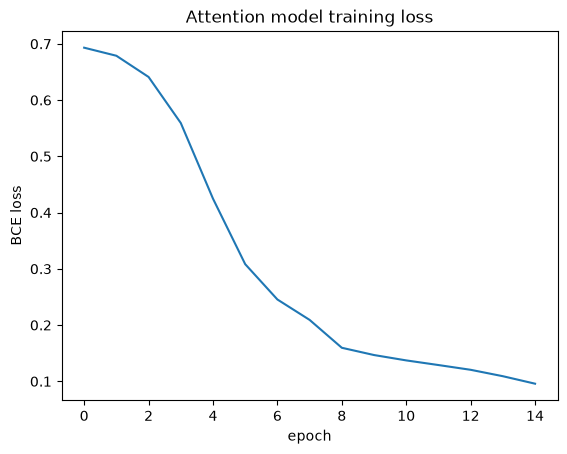

In [5]:
test_preds, test_alpha = model(X_test)
accuracy = tf.reduce_mean(tf.cast((test_preds.numpy().squeeze() >= 0.5) == (y_test >= 0.5), tf.float32)).numpy()
print(f"Test accuracy: {accuracy:.3f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Attention model training loss")
plt.show()

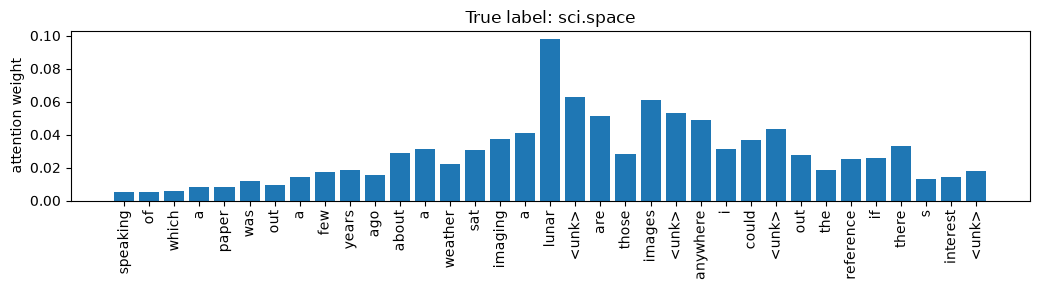

In [6]:
# Visualize attention weights for one test example
i = 0
length = int(np.sum(X_test[i] != 0))
tokens = [inv_vocab[t] for t in X_test[i, :length]]
weights = test_alpha[i, :length].numpy()

plt.figure(figsize=(max(8, length * 0.3), 3))
plt.bar(range(length), weights)
plt.xticks(range(length), tokens, rotation=90)
plt.ylabel("attention weight")
plt.title(f"True label: {test.target_names[int(y_test[i])]}")
plt.tight_layout()
plt.show()